# FinanceHub — Machine Learning Models
### Two models trained on your real dataset:
- **Model 1** — 6-Month Expense Forecast (regression)
- **Model 2** — Financial Health Score (regression) + Stress Level (classification)

---

## 0 · Setup — install all required libraries

## 1 · Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, accuracy_score, confusion_matrix
)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from xgboost import XGBRegressor, XGBClassifier

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('✅ All libraries imported successfully')




✅ All libraries imported successfully


Versions

In [2]:
import sklearn
import xgboost

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgboost.__version__)
print("Joblib version:", joblib.__version__)


Pandas version: 3.0.2
NumPy version: 2.4.4
Matplotlib version: 3.10.8
Seaborn version: 0.13.2
Scikit-learn version: 1.8.0
XGBoost version: 3.2.0
Joblib version: 1.5.3


## 2 · Load & Explore Dataset

In [3]:
# ── Load dataset ─────────────────────────────────────────────
df = pd.read_csv('combined_dataset.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (10000, 70)


,user_id,name,age,gender,city,sector,marital_status,dependents,email,phone,...,total_debt,total_monthly_emi,debt_to_income_ratio_x,savings_ratio,expense_ratio,emi_ratio,emergency_fund_months,debt_to_income_ratio_y,stress_score,stress_level
0,USER_000001,Aryan Maharaj,62,Male,Mumbai,Education,Married,1,udantdewan@example.net,918196001338,...,3650885,40737,0.2448,0.0235,0.9538,0.2448,7.27,0.2448,60,High
1,USER_000002,Rushil Saini,28,Other,Jaipur,Banking,Married,0,saumyamall@example.org,916542351161,...,113061,2826,0.0233,0.1278,0.7691,0.0233,6.39,0.0233,30,Medium
2,USER_000003,Aishani Bassi,27,Male,Hyderabad,IT,Married,2,hyadav@example.com,918495931034,...,0,0,0.0000,0.0000,1.1118,0.0000,1.92,0.0000,70,High


In [4]:
# Data types and null check
print('--- Dtypes ---')
print(df.dtypes)
print('\n--- Null values ---')
print(df.isnull().sum()[df.isnull().sum() > 0])

--- Dtypes ---
user_id                       str
name                          str
age                         int64
gender                        str
city                          str
                           ...   
emi_ratio                 float64
emergency_fund_months     float64
debt_to_income_ratio_y    float64
stress_score                int64
stress_level                  str
Length: 70, dtype: object

--- Null values ---
Series([], dtype: int64)


In [5]:
# Basic statistics for key financial columns
key_cols = [
    'total_income', 'total_monthly_expenses', 'total_investments',
    'total_debt', 'stress_score', 'savings_ratio', 'expense_ratio',
    'emergency_fund_months', 'debt_to_income_ratio_x'
]
df[key_cols].describe().round(2)

,total_income,total_monthly_expenses,total_investments,total_debt,stress_score,savings_ratio,expense_ratio,emergency_fund_months,debt_to_income_ratio_x
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,1988069.62,164552.19,3649212.18,1328487.61,63.42,0.03,1.00,4.52,0.13
std,1021916.69,87102.61,2781452.17,1614415.07,11.54,0.04,0.15,4.02,0.18
min,286810.00,24334.00,217003.00,0.00,5.00,0.00,0.61,0.09,0.00
25%,1238334.25,102121.25,1865586.75,19169.75,60.00,0.00,0.89,1.74,0.00
50%,1758154.00,144436.50,2653984.00,573437.00,65.00,0.01,0.99,3.34,0.07
75%,2504482.50,205771.25,4156208.75,2193865.50,70.00,0.05,1.09,6.05,0.20
max,7571666.00,784414.00,16029527.00,7177245.00,100.00,0.25,1.69,56.23,1.82


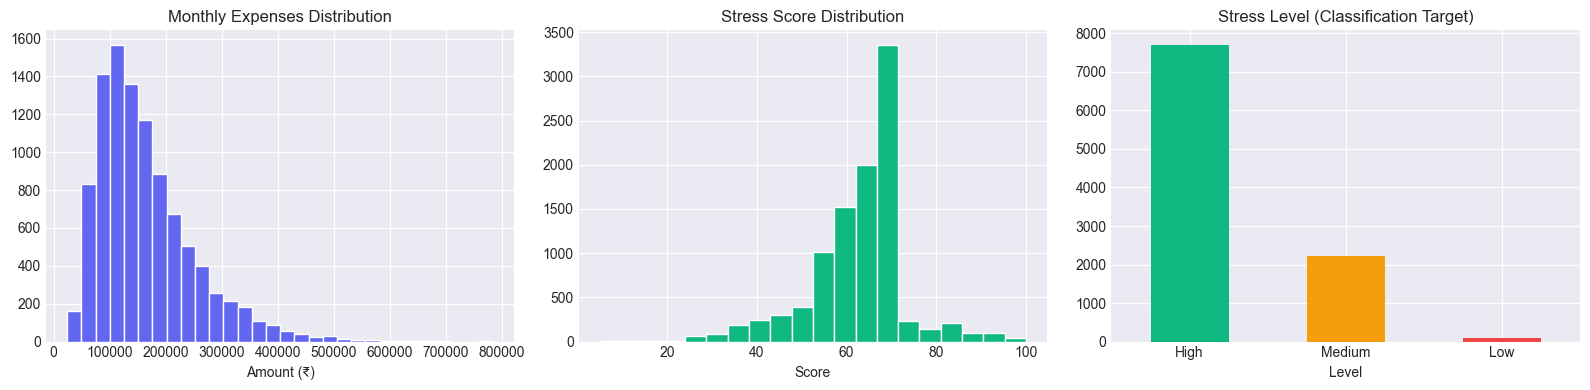

In [6]:
# Distribution of target variables
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['total_monthly_expenses'], bins=30, color='#6366f1', edgecolor='white')
axes[0].set_title('Monthly Expenses Distribution')
axes[0].set_xlabel('Amount (₹)')

axes[1].hist(df['stress_score'], bins=20, color='#10b981', edgecolor='white')
axes[1].set_title('Stress Score Distribution')
axes[1].set_xlabel('Score')

df['stress_level'].value_counts().plot(kind='bar', ax=axes[2], color=['#10b981','#f59e0b','#ef4444'])
axes[2].set_title('Stress Level (Classification Target)')
axes[2].set_xlabel('Level')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 3 · Feature Engineering & Preprocessing

In [7]:
# ── Drop columns not useful for ML ───────────────────────────
drop_cols = [
    'user_id', 'name', 'email', 'phone', 'created_at',
    'financial_year_x', 'financial_year_y', 'month'
]
df_ml = df.drop(columns=drop_cols, errors='ignore').copy()

# ── Encode categorical columns ────────────────────────────────
cat_cols = ['gender', 'city', 'sector', 'marital_status']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le

# ── Create derived features ───────────────────────────────────
df_ml['income_per_dependent'] = df_ml['total_income'] / (df_ml['dependents'] + 1)
df_ml['investment_diversity']  = (df_ml[['savings_account','fixed_deposits','mutual_funds',
                                          'stocks','ppf','epf','gold','real_estate']] > 0).sum(axis=1)
df_ml['loan_count']            = (df_ml[['home_loan','car_loan','personal_loan','education_loan']] > 0).sum(axis=1)
df_ml['monthly_income_est']    = df_ml['total_income'] / 12
df_ml['net_monthly']           = df_ml['monthly_income_est'] - df_ml['total_monthly_expenses']

print(f'Dataset shape after feature engineering: {df_ml.shape}')
print(f'New features added: income_per_dependent, investment_diversity, loan_count, monthly_income_est, net_monthly')

Dataset shape after feature engineering: (10000, 67)
New features added: income_per_dependent, investment_diversity, loan_count, monthly_income_est, net_monthly


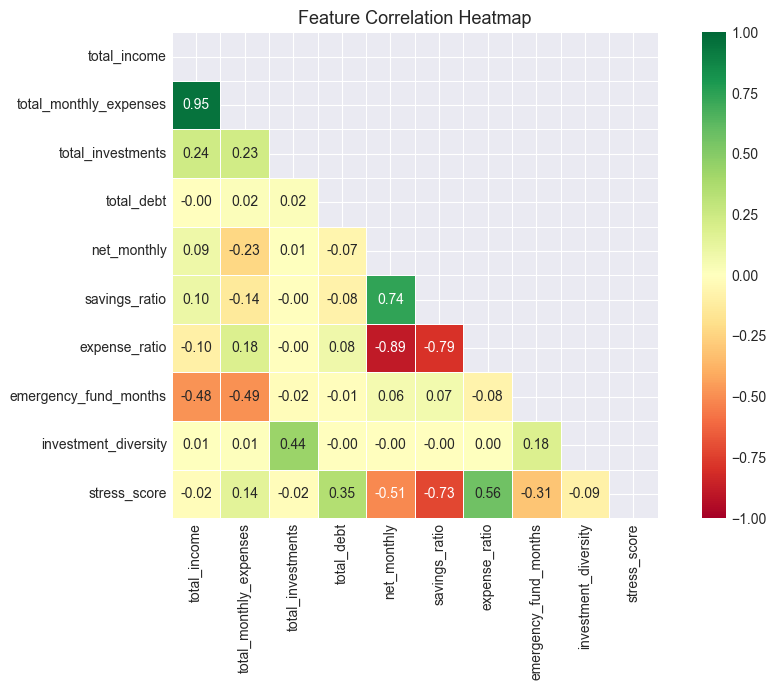

In [8]:
# ── Correlation heatmap for top features ─────────────────────
top_features = [
    'total_income', 'total_monthly_expenses', 'total_investments',
    'total_debt', 'net_monthly', 'savings_ratio', 'expense_ratio',
    'emergency_fund_months', 'investment_diversity', 'stress_score'
]
plt.figure(figsize=(10, 7))
corr = df_ml[top_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

## 4 · Model 1 — Monthly Expense Forecaster (Regression)

In [9]:
# ── Features for expense prediction ──────────────────────────
EXPENSE_FEATURES = [
    'total_income', 'monthly_income_est', 'age', 'dependents',
    'city', 'sector', 'marital_status',
    'rent', 'groceries', 'utilities', 'transportation',
    'healthcare', 'education', 'entertainment', 'shopping',
    'insurance', 'miscellaneous',
    'savings_ratio', 'expense_ratio', 'investment_diversity',
    'loan_count', 'total_monthly_emi', 'net_monthly'
]

TARGET_EXPENSE = 'total_monthly_expenses'

X_exp = df_ml[EXPENSE_FEATURES]
y_exp = df_ml[TARGET_EXPENSE]

X_tr_exp, X_te_exp, y_tr_exp, y_te_exp = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42
)

scaler_exp = StandardScaler()
X_tr_exp_s = scaler_exp.fit_transform(X_tr_exp)
X_te_exp_s = scaler_exp.transform(X_te_exp)

print(f'Train: {X_tr_exp.shape}  |  Test: {X_te_exp.shape}')

Train: (8000, 23)  |  Test: (2000, 23)


In [10]:
# ── Train multiple models & compare ──────────────────────────
exp_models = {
    'Ridge Regression'          : Ridge(alpha=1.0),
    'Random Forest'             : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'         : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'                   : XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
}

exp_results = []
for name, model in exp_models.items():
    model.fit(X_tr_exp_s, y_tr_exp)
    preds = model.predict(X_te_exp_s)
    mae   = mean_absolute_error(y_te_exp, preds)
    rmse  = np.sqrt(mean_squared_error(y_te_exp, preds))
    r2    = r2_score(y_te_exp, preds)
    exp_results.append({'Model': name, 'MAE': round(mae,0), 'RMSE': round(rmse,0), 'R²': round(r2,4)})
    print(f'{name:30s}  MAE=₹{mae:,.0f}  RMSE=₹{rmse:,.0f}  R²={r2:.4f}')

exp_results_df = pd.DataFrame(exp_results)
best_exp_name  = exp_results_df.loc[exp_results_df['R²'].idxmax(), 'Model']
print(f'\n🏆 Best model: {best_exp_name}')

Ridge Regression                MAE=₹5  RMSE=₹7  R²=1.0000
Random Forest                   MAE=₹1,406  RMSE=₹5,571  R²=0.9961
Gradient Boosting               MAE=₹3,333  RMSE=₹5,500  R²=0.9962
XGBoost                         MAE=₹2,368  RMSE=₹6,062  R²=0.9954

🏆 Best model: Ridge Regression


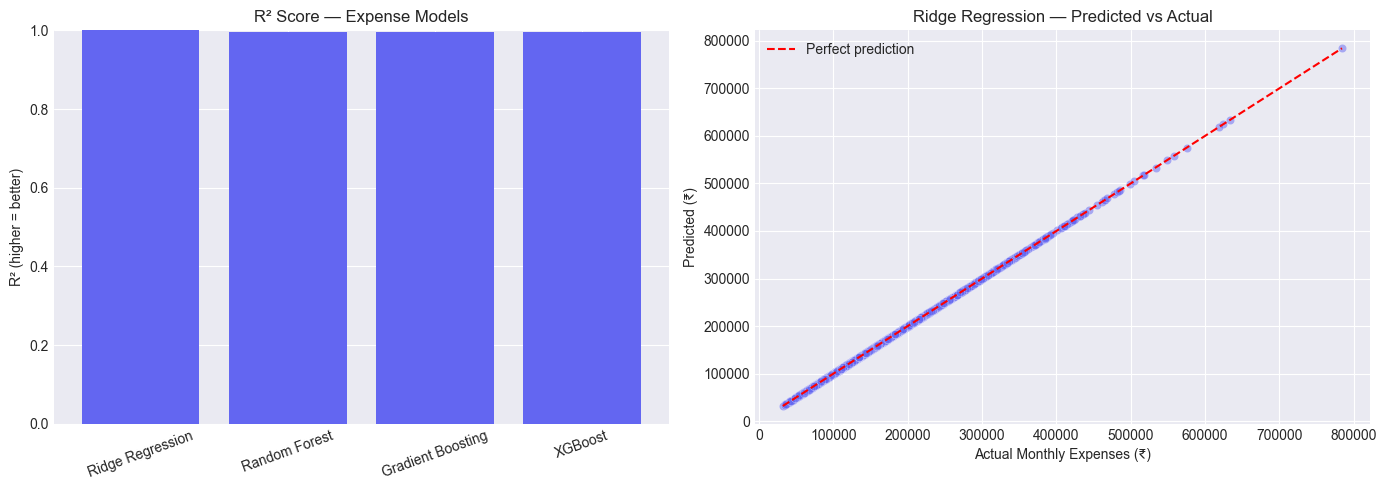

In [11]:
# ── Use best model ────────────────────────────────────────────
best_exp_model = exp_models[best_exp_name]

# Visualise model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(exp_results_df['Model'], exp_results_df['R²'], color='#6366f1')
axes[0].set_title('R² Score — Expense Models')
axes[0].set_ylabel('R² (higher = better)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, 1)

# Predicted vs Actual for best model
preds_best = best_exp_model.predict(X_te_exp_s)
axes[1].scatter(y_te_exp, preds_best, alpha=0.5, color='#6366f1', edgecolors='white', linewidth=0.3)
lim = [y_te_exp.min(), y_te_exp.max()]
axes[1].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_title(f'{best_exp_name} — Predicted vs Actual')
axes[1].set_xlabel('Actual Monthly Expenses (₹)')
axes[1].set_ylabel('Predicted (₹)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# ── Feature importance ────────────────────────────────────────
if hasattr(best_exp_model, 'feature_importances_'):
    fi = pd.Series(best_exp_model.feature_importances_, index=EXPENSE_FEATURES)
    fi = fi.sort_values(ascending=True).tail(15)
    fi.plot(kind='barh', figsize=(10, 6), color='#6366f1')
    plt.title('Top 15 Features — Expense Forecast Model')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

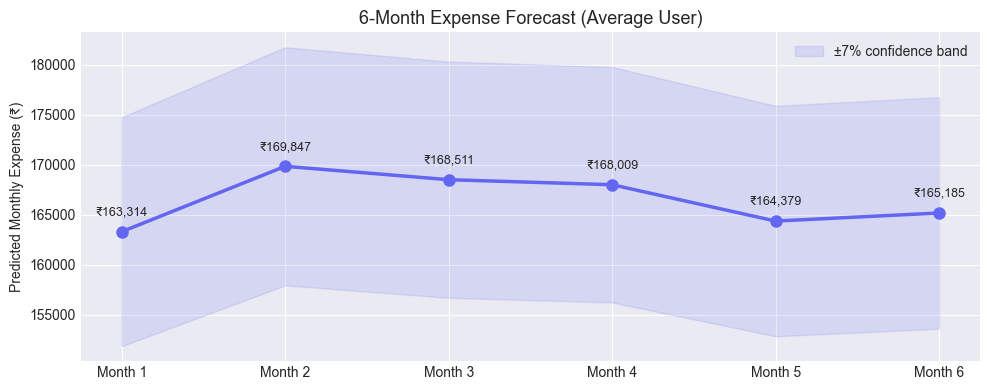

6-month forecast: [163314, 169847, 168511, 168009, 164379, 165185]


In [13]:
# ── Simulate 6-month forecast for a user ─────────────────────
def predict_6m_forecast(user_data: dict, model, scaler, features):
    """
    user_data: dict with keys matching EXPENSE_FEATURES
    Returns list of 6 monthly expense predictions with slight trend.
    """
    row = pd.DataFrame([user_data])[features]
    row_s = scaler.transform(row)
    base  = model.predict(row_s)[0]

    # Apply small realistic month-to-month variance (±3%) + gentle growth trend
    np.random.seed(42)
    forecast = []
    for i in range(6):
        noise = np.random.uniform(-0.03, 0.03)
        trend = 1 + (i * 0.005)  # 0.5% monthly inflation factor
        forecast.append(round(base * trend * (1 + noise)))
    return forecast

# Example — average user from dataset
avg_user = df_ml[EXPENSE_FEATURES].mean().to_dict()
forecast_6m = predict_6m_forecast(avg_user, best_exp_model, scaler_exp, EXPENSE_FEATURES)

months = ['Month 1', 'Month 2', 'Month 3', 'Month 4', 'Month 5', 'Month 6']
plt.figure(figsize=(10, 4))
plt.plot(months, forecast_6m, marker='o', color='#6366f1', linewidth=2.5, markersize=8)
plt.fill_between(months, [x * 0.93 for x in forecast_6m],
                           [x * 1.07 for x in forecast_6m],
                 alpha=0.15, color='#6366f1', label='±7% confidence band')
plt.title('6-Month Expense Forecast (Average User)', fontsize=13)
plt.ylabel('Predicted Monthly Expense (₹)')
for i, v in enumerate(forecast_6m):
    plt.annotate(f'₹{v:,}', (months[i], v), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()
print('6-month forecast:', forecast_6m)

## 5 · Model 2 — Financial Health Score (Regression)

In [14]:
# ── Features for health score prediction ─────────────────────
HEALTH_FEATURES = [
    'total_income', 'total_monthly_expenses', 'total_investments',
    'total_debt', 'savings_ratio', 'expense_ratio', 'emi_ratio',
    'emergency_fund_months', 'debt_to_income_ratio_x',
    'investment_diversity', 'loan_count', 'monthly_sip',
    'net_monthly', 'age', 'dependents', 'income_per_dependent',
    'section_80c', 'total_deductions'
]

TARGET_HEALTH = 'stress_score'

X_h = df_ml[HEALTH_FEATURES]
y_h = df_ml[TARGET_HEALTH]

X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

scaler_h = StandardScaler()
X_tr_h_s = scaler_h.fit_transform(X_tr_h)
X_te_h_s = scaler_h.transform(X_te_h)

print(f'Train: {X_tr_h.shape}  |  Test: {X_te_h.shape}')
print(f'Stress score range: {y_h.min()} – {y_h.max()}')

Train: (8000, 18)  |  Test: (2000, 18)
Stress score range: 5 – 100


In [15]:
# ── Train health score models ─────────────────────────────────
health_models = {
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=150, random_state=42),
    'XGBoost'           : XGBRegressor(n_estimators=150, random_state=42, verbosity=0),
}

health_results = []
for name, model in health_models.items():
    model.fit(X_tr_h_s, y_tr_h)
    preds = model.predict(X_te_h_s)
    mae   = mean_absolute_error(y_te_h, preds)
    rmse  = np.sqrt(mean_squared_error(y_te_h, preds))
    r2    = r2_score(y_te_h, preds)
    health_results.append({'Model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R²': round(r2,4)})
    print(f'{name:25s}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}')

health_results_df = pd.DataFrame(health_results)
best_h_name = health_results_df.loc[health_results_df['R²'].idxmax(), 'Model']
best_h_model = health_models[best_h_name]
print(f'\n🏆 Best model: {best_h_name}')

Ridge Regression           MAE=3.58  RMSE=4.89  R²=0.8225
Random Forest              MAE=0.12  RMSE=0.88  R²=0.9943
Gradient Boosting          MAE=0.09  RMSE=0.34  R²=0.9991
XGBoost                    MAE=0.24  RMSE=0.96  R²=0.9932

🏆 Best model: Gradient Boosting


In [16]:
# ── Convert stress score → financial health score (0–100) ─────
# Stress score is 0–100 where higher = more stressed = worse health
# We invert it: health_score = 100 - stress_score

def predict_health_score(user_data: dict, model, scaler, features):
    """
    Returns health score 0–100 (higher = healthier).
    Also returns risk flags based on key indicators.
    """
    row   = pd.DataFrame([user_data])[features]
    row_s = scaler.transform(row)
    stress = float(model.predict(row_s)[0])
    stress = max(0, min(100, stress))   # clamp
    health = round(100 - stress, 1)

    # Risk flags
    flags = []
    if user_data.get('expense_ratio', 0) > 0.7:
        flags.append('⚠ Expense ratio > 70% of income')
    if user_data.get('emergency_fund_months', 0) < 3:
        flags.append('⚠ Emergency fund below 3 months')
    if user_data.get('savings_ratio', 0) < 0.1:
        flags.append('⚠ Savings ratio below 10%')
    if user_data.get('debt_to_income_ratio_x', 0) > 0.4:
        flags.append('⚠ Debt-to-income ratio above 40%')
    if user_data.get('investment_diversity', 0) < 2:
        flags.append('⚠ Low investment diversification')

    return health, flags

# Test on average user
avg_health_user = df_ml[HEALTH_FEATURES].mean().to_dict()
score, flags = predict_health_score(avg_health_user, best_h_model, scaler_h, HEALTH_FEATURES)
print(f'Average user health score: {score}/100')
print('Risk flags:')
for f in flags: print(' ', f)

Average user health score: 35.0/100
Risk flags:
  ⚠ Expense ratio > 70% of income
  ⚠ Savings ratio below 10%


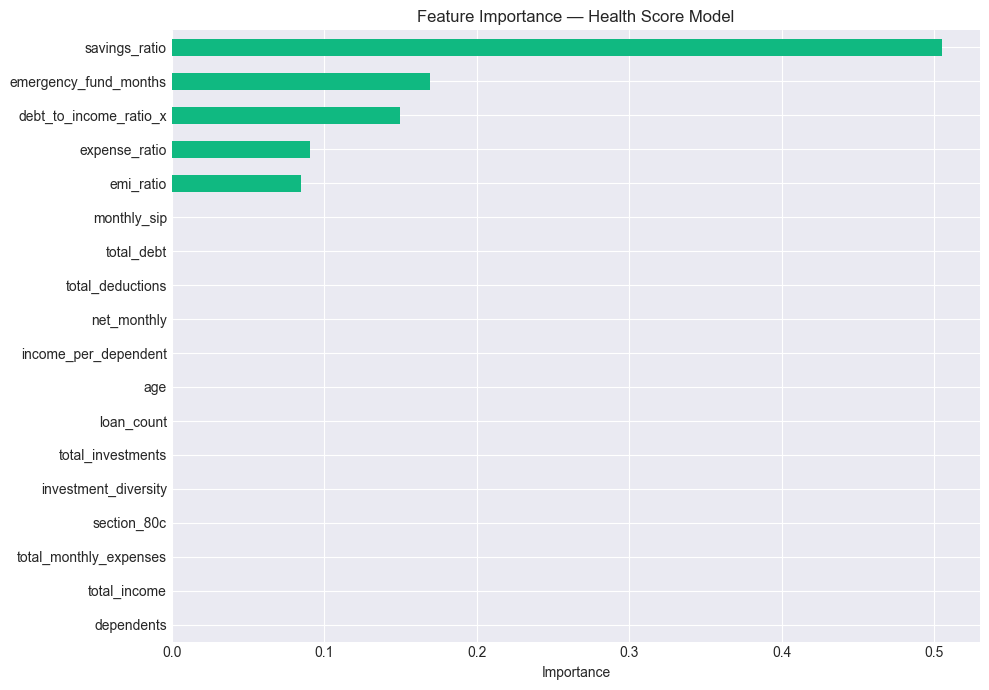

In [17]:
# ── Feature importance for health model ──────────────────────
if hasattr(best_h_model, 'feature_importances_'):
    fi_h = pd.Series(best_h_model.feature_importances_, index=HEALTH_FEATURES)
    fi_h = fi_h.sort_values(ascending=True)
    fi_h.plot(kind='barh', figsize=(10, 7), color='#10b981')
    plt.title('Feature Importance — Health Score Model')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

## 6 · Model 3 — Stress Level Classifier (Low / Medium / High)

In [18]:
# ── Encode stress level target ────────────────────────────────
le_stress = LabelEncoder()
y_stress = le_stress.fit_transform(df_ml['stress_level'])
print('Classes:', le_stress.classes_)   # alphabetical: High=0, Low=1, Medium=2

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_h, y_stress, test_size=0.2, random_state=42
)

# Re-use same scaler_h (same features)
X_tr_s_sc = scaler_h.transform(X_tr_s)
X_te_s_sc = scaler_h.transform(X_te_s)

# Train XGBoost classifier
clf = XGBClassifier(n_estimators=150, random_state=42, verbosity=0, use_label_encoder=False,
                    eval_metric='mlogloss')
clf.fit(X_tr_s_sc, y_tr_s)
y_pred_s = clf.predict(X_te_s_sc)

print(f'\nAccuracy: {accuracy_score(y_te_s, y_pred_s):.4f}')
print('\nClassification Report:')
print(classification_report(y_te_s, y_pred_s, target_names=le_stress.classes_))

Classes: ['High' 'Low' 'Medium']

Accuracy: 0.9960

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1529
         Low       0.95      0.90      0.93        21
      Medium       0.99      0.99      0.99       450

    accuracy                           1.00      2000
   macro avg       0.98      0.96      0.97      2000
weighted avg       1.00      1.00      1.00      2000



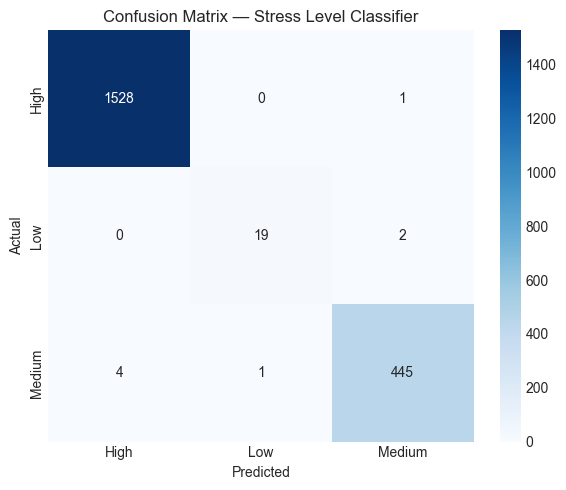

In [19]:
# ── Confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(y_te_s, y_pred_s)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_stress.classes_,
            yticklabels=le_stress.classes_)
plt.title('Confusion Matrix — Stress Level Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 7 · Save All Models

In [20]:
import os
os.makedirs('models', exist_ok=True)

# ── Save with joblib ──────────────────────────────────────────
joblib.dump(best_exp_model, 'models/expense_forecast_model.pkl')
joblib.dump(scaler_exp,     'models/expense_scaler.pkl')

joblib.dump(best_h_model,   'models/health_score_model.pkl')
joblib.dump(scaler_h,       'models/health_scaler.pkl')

joblib.dump(clf,            'models/stress_classifier.pkl')
joblib.dump(le_stress,      'models/stress_label_encoder.pkl')

# ── Save feature lists as JSON (needed for app.js integration) 
meta = {
    'expense_features' : EXPENSE_FEATURES,
    'health_features'  : HEALTH_FEATURES,
    'stress_classes'   : list(le_stress.classes_),
    'best_expense_model': best_exp_name,
    'best_health_model' : best_h_name,
}
with open('models/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('✅ All models saved to /models folder:')
for fn in os.listdir('models'):
    size = os.path.getsize(f'models/{fn}') / 1024
    print(f'  {fn}  ({size:.1f} KB)')

✅ All models saved to /models folder:
  expense_forecast_model.pkl  (0.7 KB)
  expense_scaler.pkl  (1.6 KB)
  health_scaler.pkl  (1.5 KB)
  health_score_model.pkl  (201.4 KB)
  model_meta.json  (1.1 KB)
  stress_classifier.pkl  (475.3 KB)
  stress_label_encoder.pkl  (0.5 KB)


## 8 · End-to-End Prediction Demo

In [21]:
# ── Test with a realistic user profile ───────────────────────
test_user = {
    # Income
    'total_income'         : 1_500_000,
    'monthly_income_est'   : 125_000,
    'age'                  : 32,
    'dependents'           : 1,
    'gender'               : 1,  # encoded
    'city'                 : 2,  # encoded
    'sector'               : 3,  # encoded
    'marital_status'       : 1,  # encoded
    # Monthly expenses
    'rent'                 : 25_000,
    'groceries'            : 10_000,
    'utilities'            : 3_000,
    'transportation'       : 6_000,
    'healthcare'           : 2_000,
    'education'            : 0,
    'entertainment'        : 4_000,
    'shopping'             : 5_000,
    'insurance'            : 3_000,
    'miscellaneous'        : 2_000,
    # Investments
    'total_investments'    : 800_000,
    'monthly_sip'          : 10_000,
    'savings_account'      : 200_000,
    'fixed_deposits'       : 300_000,
    'mutual_funds'         : 150_000,
    'stocks'               : 100_000,
    'ppf'                  : 50_000,
    'epf'                  : 0,
    'gold'                 : 0,
    'real_estate'          : 0,
    # Debt
    'total_debt'           : 2_000_000,
    'home_loan'            : 2_000_000,
    'car_loan'             : 0,
    'personal_loan'        : 0,
    'education_loan'       : 0,
    'total_monthly_emi'    : 18_000,
    'emergency_fund'       : 200_000,
    # Ratios / derived
    'savings_ratio'        : 0.18,
    'expense_ratio'        : 0.48,
    'emi_ratio'            : 0.144,
    'emergency_fund_months': 3.3,
    'debt_to_income_ratio_x': 0.144,
    'debt_to_income_ratio_y': 0.144,
    # Deductions
    'section_80c'          : 150_000,
    'total_deductions'     : 200_000,
    # Derived features
    'income_per_dependent' : 750_000,
    'investment_diversity' : 4,
    'loan_count'           : 1,
    'net_monthly'          : 65_000,
}

# ── Auto-compute total_monthly_expenses from individual fields ──
_expense_fields = [
    'rent', 'groceries', 'utilities', 'transportation',
    'healthcare', 'education', 'entertainment',
    'shopping', 'insurance', 'miscellaneous'
]
test_user['total_monthly_expenses'] = sum(test_user[k] for k in _expense_fields)
print(f"✅ total_monthly_expenses = ₹{test_user['total_monthly_expenses']:,}")

# ── Sanity check: verify all required features are present ─────
missing_exp = [f for f in EXPENSE_FEATURES if f not in test_user]
missing_hlt = [f for f in HEALTH_FEATURES  if f not in test_user]
if missing_exp:
    print(f"❌ Missing from EXPENSE_FEATURES: {missing_exp}")
if missing_hlt:
    print(f"❌ Missing from HEALTH_FEATURES:  {missing_hlt}")
if not missing_exp and not missing_hlt:
    print("✅ All required features present — running predictions...\n")

# ── Run expense forecast ───────────────────────────────────────
forecast = predict_6m_forecast(test_user, best_exp_model, scaler_exp, EXPENSE_FEATURES)
print('📊 6-Month Expense Forecast:')
for i, amt in enumerate(forecast, 1):
    print(f'  Month {i}: ₹{amt:,}')

# ── Run health score ───────────────────────────────────────────
score, flags = predict_health_score(test_user, best_h_model, scaler_h, HEALTH_FEATURES)
print(f'\n💚 Financial Health Score: {score}/100')

# ── Run stress classifier ──────────────────────────────────────
row_s  = pd.DataFrame([test_user])[HEALTH_FEATURES]
row_sc = scaler_h.transform(row_s)
stress_pred = le_stress.inverse_transform(clf.predict(row_sc))[0]
stress_prob = clf.predict_proba(row_sc)[0]
print(f'🎯 Stress Level: {stress_pred}')
print(f'   Probabilities: { {c: round(p, 3) for c, p in zip(le_stress.classes_, stress_prob)} }')

if flags:
    print('\n🚩 Risk Flags:')
    for f in flags:
        print(' ', f)
else:
    print('\n✅ No risk flags — finances look healthy!')

✅ total_monthly_expenses = ₹60,000
✅ All required features present — running predictions...

📊 6-Month Expense Forecast:
  Month 1: ₹59,534
  Month 2: ₹61,916
  Month 3: ₹61,429
  Month 4: ₹61,246
  Month 5: ₹59,922
  Month 6: ₹60,216

💚 Financial Health Score: 75.3/100
🎯 Stress Level: Low
   Probabilities: {'High': np.float32(0.0), 'Low': np.float32(0.987), 'Medium': np.float32(0.013)}

✅ No risk flags — finances look healthy!


## 9 · Load & Use Saved Models (Production Usage)

In [22]:
# ── Example: load from disk and predict ──────────────────────
exp_model_loaded  = joblib.load('models/expense_forecast_model.pkl')
exp_scaler_loaded = joblib.load('models/expense_scaler.pkl')
h_model_loaded    = joblib.load('models/health_score_model.pkl')
h_scaler_loaded   = joblib.load('models/health_scaler.pkl')
clf_loaded        = joblib.load('models/stress_classifier.pkl')
le_loaded         = joblib.load('models/stress_label_encoder.pkl')

# Quick sanity check
f2 = predict_6m_forecast(test_user, exp_model_loaded, exp_scaler_loaded, EXPENSE_FEATURES)
s2,_ = predict_health_score(test_user, h_model_loaded, h_scaler_loaded, HEALTH_FEATURES)
print(f'✅ Models loaded from disk successfully')
print(f'   Expense forecast month 1: ₹{f2[0]:,}')
print(f'   Health score            : {s2}/100')

✅ Models loaded from disk successfully
   Expense forecast month 1: ₹59,534
   Health score            : 75.3/100


---
## Summary

| Model | Purpose | Algorithm | Output |
|---|---|---|---|
| Expense Forecaster | Predict monthly spend | Best of Ridge/RF/GB/XGB | 6 monthly ₹ amounts |
| Health Scorer | Financial fitness | Best of Ridge/RF/GB/XGB | Score 0–100 + risk flags |
| Stress Classifier | Risk level | XGBoost Classifier | Low / Medium / High |

**Saved files in `/models/`:**
- `expense_forecast_model.pkl` + `expense_scaler.pkl`
- `health_score_model.pkl` + `health_scaler.pkl`
- `stress_classifier.pkl` + `stress_label_encoder.pkl`
- `model_meta.json` — feature lists for app integration